In [8]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = california_housing.load_data(version="small")

In [9]:
# Normalizing data

# Normalize input
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std # normalization of test-data based on training-data (never use test-data for that)

# Normalize outputs (targets)
y_train = train_targets / 100000
y_test = test_targets / 100000

In [10]:
from keras import layers
import keras

def get_model():
    model = keras.Sequential([ # no activation function since we do not want to restrict the outcome value
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1) # Typical for a scalar regression (prediction of a single continuous value)
    ])
    model.compile(
        optimizer="adam",
        loss="mean_squared_error", # typical for regression
        metrics=["mean_absolute_error"],
    )
    return model

In [13]:
import numpy as np

# K-fold validation (required due to small data set -> validation set would be super small -> high variance

k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_scores = []

for i in range(k):

    print(f"Processing fold #{i + 1}")

    fold_x_val = x_train[i * num_val_samples: (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples: (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[:i * num_val_samples],
         x_train[(i + 1) * num_val_samples:]],
        axis=0)
    fold_y_train = np.concatenate(
        [y_train[:i * num_val_samples],
         y_train[(i + 1) * num_val_samples:]],
        axis=0)
    model = get_model()
    model.fit(fold_x_train, fold_y_train,
              epochs=num_epochs, batch_size=16, verbose=0)
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)


Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [15]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples: (i + 1) * num_val_samples] #1
    fold_y_val = y_train[i * num_val_samples: (i + 1) * num_val_samples]
    fold_x_train = np.concatenate( #2
        [x_train[:i * num_val_samples],
         x_train[(i + 1) * num_val_samples:]],
        axis=0)
    fold_y_train = np.concatenate(
        [y_train[:i * num_val_samples],
         y_train[(i + 1) * num_val_samples:]],
        axis=0)
    model = get_model() #3
    history = model.fit(fold_x_train, fold_y_train, #4
                        validation_data=(fold_x_val, fold_y_val),
                        epochs=num_epochs, batch_size=16, verbose=0)
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]



Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


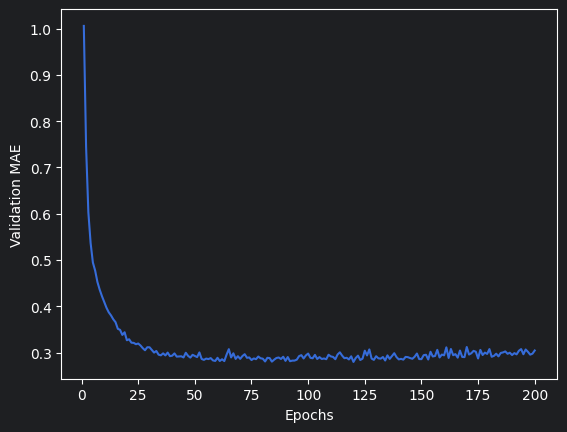

In [17]:
from matplotlib import pyplot as plt

epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.savefig("california_housing_validation_mae_plot.png", dpi=300)

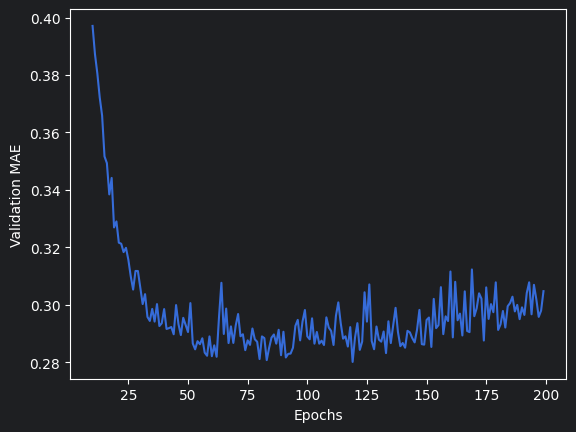

In [19]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.savefig("california_housing_validation_mae_plot_zoomed.png", dpi=300)

In [24]:
model = get_model() #1
model.fit(x_train, y_train, #2
          epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3037 - mean_absolute_error: 0.3110  


In [25]:
predictions = model.predict(test_data)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([2482.3027], dtype=float32)